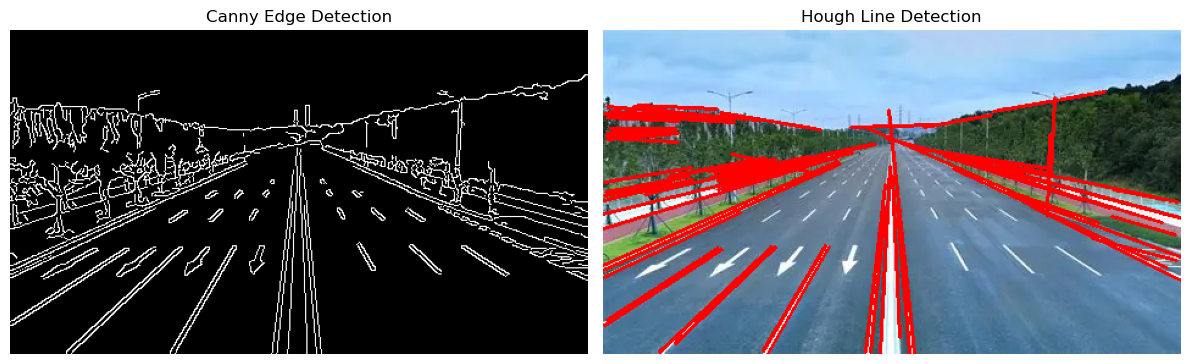

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Notebook配置：图片内嵌显示、支持中文
%matplotlib inline
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 1. 读取图像
img = cv2.imread('road.png')
if img is None:
    raise FileNotFoundError("未找到road.png！检查文件名/路径")

# 2. 图像预处理：灰度+高斯模糊+Canny边缘检测
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # 转灰度图
blur = cv2.GaussianBlur(gray, (5, 5), 0)      # 高斯模糊降噪
edges = cv2.Canny(blur, 50, 150)              # 提取边缘

# 3. 霍夫直线检测（概率霍夫变换）
lines = cv2.HoughLinesP(
    edges,
    rho=1,                # 距离精度1像素
    theta=np.pi/180,      # 角度精度1度
    threshold=50,         # 投票阈值
    minLineLength=50,     # 最短直线长度
    maxLineGap=10         # 直线断点最大间距
)

# 4. 绘制检测到的直线
img_lines = img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_lines, (x1, y1), (x2, y2), (0, 0, 255), 2)  # 红色直线，线宽2
else:
    print("未检测到有效直线！可降低threshold参数")

# 5. 可视化结果
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# 显示边缘检测结果
ax1.imshow(edges, cmap='gray')
ax1.set_title('Canny Edge Detection', fontsize=12)
ax1.axis('off')

# 显示直线检测结果
ax2.imshow(cv2.cvtColor(img_lines, cv2.COLOR_BGR2RGB))
ax2.set_title('Hough Line Detection', fontsize=12)
ax2.axis('off')

plt.tight_layout()
plt.show()